# Notebook 7 — Feature-Guided Transformer

## Objective

The previous notebooks progressively developed Transformer-based models for stock price prediction, beginning with a standard PyTorch implementation, followed by a custom Transformer and a Price-Aware Transformer.

While the Price-Aware Transformer introduced domain-specific inductive bias, it relied only on raw closing prices and ignored the rich financial indicators engineered during preprocessing.

This notebook proposes a Feature-Guided Transformer that directly incorporates engineered financial indicators into the attention mechanism.

Rather than constructing attention biases from raw prices, the model builds contextual representations from groups of financial indicators describing price behaviour, returns, volatility, momentum, trend, volume, candlestick structure and market structure.

This allows the Transformer to exploit financial knowledge already present in the feature engineering pipeline while preserving the standard scaled dot-product attention framework.

## Contributions

- Uses engineered financial indicators directly during attention.
- Groups related indicators into meaningful financial concepts.
- Learns attention biases from feature groups instead of handcrafted formulas.
- Maintains compatibility with the existing Transformer architecture.
- Compares against all previous models using regression and trading metrics.

In [1]:
import joblib

feature_columns = joblib.load("pipeline/feature_columns.pkl")
print(", ".join(f"'{col}'" for col in feature_columns))

'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Rolling_Volatility', 'Return', 'Log_Return', 'Price_Change', 'Previous_Close', 'Gap', 'High_Low_Range', 'Open_Close_Range', 'True_Range', 'Rolling_Mean', 'Rolling_STD', 'Rolling_Min', 'Rolling_Max', 'Rolling_Median', 'Rolling_Variance', 'Momentum_5', 'Momentum_10', 'Momentum_20', 'ROC_5', 'ROC_10', 'Volume_MA_5', 'Volume_MA_20', 'Relative_Volume', 'Volume_Change', 'Volume_Momentum', 'OBV', 'VWAP', 'Body', 'Upper_Wick', 'Lower_Wick', 'Full_Range', 'Body_Ratio', 'Upper_Wick_Ratio', 'Lower_Wick_Ratio', 'Body_to_Wick', 'ATR', 'Historical_Volatility', 'Parkinson_Volatility', 'Garman_Klass', 'EMA_9', 'EMA_21', 'EMA_50', 'EMA_200', 'MACD', 'EMA_12', 'EMA_26', 'Signal', 'MACD_Histogram', 'Rolling_Skew', 'Rolling_Kurtosis', 'Rolling_Zscore', 'Rolling_Max_Return', 'Rolling_Min_Return', 'Rolling_Return_STD', 'Day', 'Month', 'Quarter', 'DayOfWeek', 'WeekOfYear', 'Close_Lag_1', 'Return_Lag_1', 'Volume_Lag_1', 'Close_Lag_2', 'Return_Lag_2', 

In [2]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from pipeline.metrics import evaluate_trading_metrics

In [3]:
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [4]:
X_train=np.load("pipeline/X_train.npy")
X_val=np.load("pipeline/X_val.npy")
X_test=np.load("pipeline/X_test.npy")

y_train=np.load("pipeline/y_train.npy")
y_val=np.load("pipeline/y_val.npy")
y_test=np.load("pipeline/y_test.npy")

In [5]:
feature_columns=joblib.load("pipeline/feature_columns.pkl")

feature_idx={name:i for i,name in enumerate(feature_columns)}

print(f"Number of Features: {len(feature_columns)}")
print(feature_columns[:10])

Number of Features: 95
['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Rolling_Volatility', 'Return', 'Log_Return', 'Price_Change']


In [6]:
FEATURE_GROUPS={
    "price":[
        "Close","High","Low","Open","Previous_Close"
    ],

    "returns":[
        "Daily_Return","Return","Log_Return","Price_Change"
    ],

    "volatility":[
        "Rolling_Volatility","Rolling_STD","ATR",
        "Historical_Volatility","Parkinson_Volatility",
        "Garman_Klass","Rolling_Return_STD"
    ],

    "momentum":[
        "Momentum_5","Momentum_10","Momentum_20",
        "ROC_5","ROC_10"
    ],

    "trend":[
        "EMA_9","EMA_21","EMA_50","EMA_200",
        "MACD","Signal","MACD_Histogram"
    ],

    "volume":[
        "Volume","Volume_MA_5","Volume_MA_20",
        "Relative_Volume","Volume_Change",
        "Volume_Momentum","OBV","VWAP"
    ],

    "candlestick":[
        "Body","Upper_Wick","Lower_Wick",
        "Body_Ratio","Upper_Wick_Ratio",
        "Lower_Wick_Ratio","Body_to_Wick"
    ],

    "market_structure":[
        "Rolling_High_20","Rolling_Low_20",
        "Distance_From_High_20",
        "Distance_From_Low_20",
        "Breakout_20","Breakdown_20"
    ]
}

In [7]:
GROUP_INDICES={
    group:[feature_idx[f] for f in features]
    for group,features in FEATURE_GROUPS.items()
}

for group,idx in GROUP_INDICES.items():
    print(f"{group:18s} -> {len(idx)} features")

price              -> 5 features
returns            -> 4 features
volatility         -> 7 features
momentum           -> 5 features
trend              -> 7 features
volume             -> 8 features
candlestick        -> 7 features
market_structure   -> 6 features


In [8]:
X_train=torch.tensor(X_train,dtype=torch.float32).to(DEVICE)
X_val=torch.tensor(X_val,dtype=torch.float32).to(DEVICE)
X_test=torch.tensor(X_test,dtype=torch.float32).to(DEVICE)

y_train=torch.tensor(y_train,dtype=torch.float32).to(DEVICE)
y_val=torch.tensor(y_val,dtype=torch.float32).to(DEVICE)
y_test=torch.tensor(y_test,dtype=torch.float32).to(DEVICE)

In [9]:
from torch.utils.data import TensorDataset,DataLoader

In [10]:
BATCH_SIZE=64

train_dataset=TensorDataset(X_train,y_train)
val_dataset=TensorDataset(X_val,y_val)

train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [11]:
SEQ_LENGTH=X_train.shape[1]
INPUT_DIM=X_train.shape[2]

D_MODEL=128
NUM_HEADS=8
FF_DIM=256
NUM_LAYERS=2

DROPOUT=0.1

LEARNING_RATE=1e-3
EPOCHS=30
PATIENCE=7

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len=5000):
        super().__init__()

        pe=torch.zeros(max_len,d_model)

        position=torch.arange(max_len,dtype=torch.float32).unsqueeze(1)

        div_term=torch.exp(torch.arange(0,d_model,2,dtype=torch.float32)*(-math.log(10000.0)/d_model))

        pe[:,0::2]=torch.sin(position*div_term)
        pe[:,1::2]=torch.cos(position*div_term)

        self.register_buffer("pe",pe.unsqueeze(0))

    def forward(self,x):
        return x+self.pe[:,:x.size(1)]

In [13]:
pe=PositionalEncoding(D_MODEL)
print(pe.pe.shape)

torch.Size([1, 5000, 128])


## Feature Context Module

Instead of constructing attention biases from handcrafted price differences, each financial feature group is projected into a latent representation.

For every feature group:

1. Extract engineered indicators.
2. Project them into a shared embedding space.
3. Compute pairwise similarity between timesteps.

These similarity matrices are later incorporated into the attention mechanism as learnable financial context.

In [14]:
class FeatureContextModule(nn.Module):
    def __init__(self,d_head):
        super().__init__()

        self.projections=nn.ModuleDict({
            group:nn.Linear(len(indices),d_head)
            for group,indices in GROUP_INDICES.items()
        })

    def forward(self,x):

        contexts={}

        for group,indices in GROUP_INDICES.items():

            features=x[:,:,indices]

            embedding=self.projections[group](features)

            embedding=F.normalize(embedding,p=2,dim=-1)

            similarity=torch.matmul(
                embedding,
                embedding.transpose(-2,-1)
            )

            contexts[group]=similarity

        return contexts

In [15]:
context=FeatureContextModule(16).to(DEVICE)

contexts=context(X_train[:2])

for name,matrix in contexts.items():
    print(name,matrix.shape)

price torch.Size([2, 60, 60])
returns torch.Size([2, 60, 60])
volatility torch.Size([2, 60, 60])
momentum torch.Size([2, 60, 60])
trend torch.Size([2, 60, 60])
volume torch.Size([2, 60, 60])
candlestick torch.Size([2, 60, 60])
market_structure torch.Size([2, 60, 60])


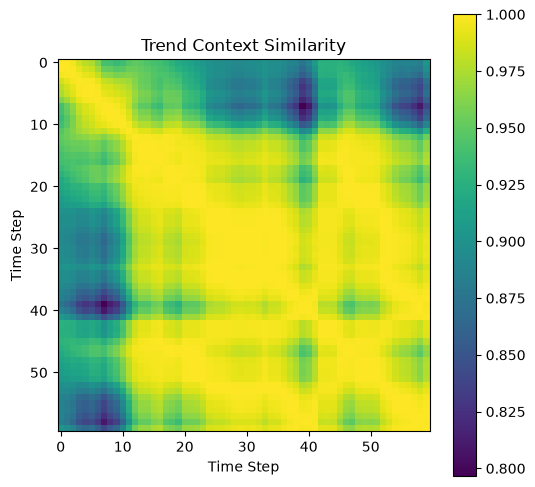

In [16]:
plt.figure(figsize=(6,6))
plt.imshow(contexts["trend"][0].detach().cpu().numpy(),cmap="viridis")
plt.colorbar()
plt.title("Trend Context Similarity")
plt.xlabel("Time Step")
plt.ylabel("Time Step")
plt.show()

## Feature-Guided Attention

The standard scaled dot-product attention computes attention scores using only the similarity between queries and keys.

This module extends the attention mechanism by incorporating contextual similarity matrices computed from engineered financial indicators.

Each financial feature group contributes a learnable bias term whose importance is optimized during training.

In [17]:
class FeatureGuidedAttention(nn.Module):
    def __init__(self,d_k,num_heads):
        super().__init__()

        self.scale=math.sqrt(d_k)

        self.context=FeatureContextModule(d_k)

        self.group_weights=nn.ParameterDict({
            group:nn.Parameter(torch.zeros(num_heads,1,1))
            for group in GROUP_INDICES.keys()
        })

    def forward(self,Q,K,V,features):

        scores=torch.matmul(Q,K.transpose(-2,-1))/self.scale

        contexts=self.context(features)

        for group,matrix in contexts.items():
            weight=torch.sigmoid(self.group_weights[group])
            scores=scores+weight.unsqueeze(0)*matrix.unsqueeze(1)

        weights=F.softmax(scores,dim=-1)

        output=torch.matmul(weights,V)

        return output,weights

In [18]:
attention=FeatureGuidedAttention(16,NUM_HEADS).to(DEVICE)

Q=torch.randn(2,NUM_HEADS,SEQ_LENGTH,16).to(DEVICE)
K=torch.randn(2,NUM_HEADS,SEQ_LENGTH,16).to(DEVICE)
V=torch.randn(2,NUM_HEADS,SEQ_LENGTH,16).to(DEVICE)

out,weights=attention(Q,K,V,X_train[:2])

print(out.shape)
print(weights.shape)

torch.Size([2, 8, 60, 16])
torch.Size([2, 8, 60, 60])


In [19]:
for group,param in attention.group_weights.items():
    print(group)

    print(torch.sigmoid(param).detach().cpu().flatten())

candlestick
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
market_structure
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
momentum
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
price
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
returns
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
trend
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
volatility
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
volume
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])


## Feature-Guided Multi-Head Attention

The Feature-Guided Attention module is applied independently to each attention head.

Queries, keys and values are computed using standard linear projections, while financial context is incorporated through the attention scores.

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_model,num_heads):
        super().__init__()

        assert d_model%num_heads==0

        self.num_heads=num_heads
        self.head_dim=d_model//num_heads

        self.q_proj=nn.Linear(d_model,d_model)
        self.k_proj=nn.Linear(d_model,d_model)
        self.v_proj=nn.Linear(d_model,d_model)

        self.attention=FeatureGuidedAttention(
            self.head_dim,
            self.num_heads
        )

        self.out_proj=nn.Linear(d_model,d_model)

    def forward(self,x,raw_features):

        B,L,_=x.shape

        Q=self.q_proj(x).view(B,L,self.num_heads,self.head_dim).transpose(1,2)
        K=self.k_proj(x).view(B,L,self.num_heads,self.head_dim).transpose(1,2)
        V=self.v_proj(x).view(B,L,self.num_heads,self.head_dim).transpose(1,2)

        out,weights=self.attention(
            Q,
            K,
            V,
            raw_features
        )

        out=out.transpose(1,2).contiguous().view(B,L,-1)

        out=self.out_proj(out)

        return out,weights

In [21]:
mha=MultiHeadAttention(D_MODEL,NUM_HEADS).to(DEVICE)

dummy=torch.randn(4,SEQ_LENGTH,D_MODEL).to(DEVICE)

out,weights=mha(dummy,X_train[:4])

print(out.shape)
print(weights.shape)

torch.Size([4, 60, 128])
torch.Size([4, 8, 60, 60])


## Feed Forward Network

Each encoder block contains a position-wise feed forward network that transforms token representations independently after the attention layer.

In [22]:
class FeedForward(nn.Module):
    def __init__(self,d_model,ff_dim,dropout=0.1):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(d_model,ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim,d_model)
        )

    def forward(self,x):
        return self.net(x)

## Encoder Block

Each encoder block combines:

- Feature-Guided Multi-Head Attention
- Residual Connection
- Layer Normalization
- Feed Forward Network
- Residual Connection
- Layer Normalization

In [23]:
class EncoderBlock(nn.Module):
    def __init__(self,d_model,num_heads,ff_dim,dropout=0.1):
        super().__init__()

        self.attention=MultiHeadAttention(d_model,num_heads)

        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)

        self.ffn=FeedForward(d_model,ff_dim,dropout)

        self.dropout=nn.Dropout(dropout)

    def forward(self,x,raw_features):

        attn_out,weights=self.attention(x,raw_features)

        x=self.norm1(x+self.dropout(attn_out))

        ff_out=self.ffn(x)

        x=self.norm2(x+self.dropout(ff_out))

        return x,weights

In [24]:
class AttentionPooling(nn.Module):
    def __init__(self,d_model):
        super().__init__()
        self.score=nn.Linear(d_model,1)

    def forward(self,x):

        weights=torch.softmax(self.score(x),dim=1)

        pooled=(weights*x).sum(dim=1)

        return pooled

## Feature-Guided Transformer

The complete model consists of:

- Input Projection
- Positional Encoding
- Feature-Guided Encoder Stack
- Learnable Attention Pooling
- Regression Head

In [25]:
class FeatureGuidedTransformer(nn.Module):
    def __init__(self,input_dim,d_model,num_heads,ff_dim,num_layers,dropout=0.1):
        super().__init__()

        self.embedding=nn.Linear(input_dim,d_model)
        self.position=PositionalEncoding(d_model)
        self.dropout=nn.Dropout(dropout)

        self.cls_token=nn.Parameter(torch.zeros(1,1,d_model))
        nn.init.trunc_normal_(self.cls_token,std=0.02)

        self.layers=nn.ModuleList([
            EncoderBlock(d_model,num_heads,ff_dim,dropout)
            for _ in range(num_layers)
        ])

        self.regressor=nn.Linear(d_model,1)

    def forward(self,x):

        raw_features=x

        x=self.embedding(x)

        B=x.size(0)

        cls=self.cls_token.expand(B,-1,-1)

        x=torch.cat([cls,x],dim=1)

        zeros=torch.zeros(B,1,raw_features.size(2),device=x.device)

        raw_features=torch.cat([zeros,raw_features],dim=1)

        x=self.position(x)

        x=self.dropout(x)

        attention_maps=[]

        for layer in self.layers:
            x,weights=layer(x,raw_features)
            attention_maps.append(weights)

        cls_output=x[:,0]

        pred=self.regressor(cls_output).squeeze(-1)

        return pred,attention_maps

In [26]:
model=FeatureGuidedTransformer(
    INPUT_DIM,
    D_MODEL,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS,
    DROPOUT
).to(DEVICE)

print(model)

FeatureGuidedTransformer(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attention): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): FeatureGuidedAttention(
          (context): FeatureContextModule(
            (projections): ModuleDict(
              (price): Linear(in_features=5, out_features=16, bias=True)
              (returns): Linear(in_features=4, out_features=16, bias=True)
              (volatility): Linear(in_features=7, out_features=16, bias=True)
              (momentum): Linear(in_features=5, out_features=16, bias=True)
              (trend): Linear(in_features=7, out_features=16, bias=True)
              (volume)

In [27]:
dummy=torch.randn(8,SEQ_LENGTH,INPUT_DIM).to(DEVICE)

pred,attention=model(dummy)

print(pred.shape)
print(len(attention))
print(attention[0].shape)

torch.Size([8])
2
torch.Size([8, 8, 61, 61])


## Training Configuration

The model is trained using:

- Mean Squared Error loss
- AdamW optimizer
- ReduceLROnPlateau scheduler
- Mixed Precision Training (CUDA only)
- Gradient Clipping
- Early Stopping

In [29]:
criterion=nn.MSELoss()

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
    betas=(0.9,0.95)
)

scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

use_amp=DEVICE.type=="cuda"

if use_amp:
    scaler=torch.amp.GradScaler("cuda")

In [30]:
best_loss=float("inf")
best_epoch=0
patience_counter=0

train_losses=[]
val_losses=[]

start_time=time.time()

In [31]:
for epoch in range(EPOCHS):

    model.train()

    train_loss=0

    for X_batch,y_batch in train_loader:

        optimizer.zero_grad()

        if use_amp:

            with torch.amp.autocast("cuda"):

                pred,_=model(X_batch)

                loss=criterion(pred,y_batch)

            scaler.scale(loss).backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

            scaler.step(optimizer)

            scaler.update()

        else:

            pred,_=model(X_batch)

            loss=criterion(pred,y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

            optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    model.eval()

    val_loss=0

    with torch.no_grad():

        for X_batch,y_batch in val_loader:

            if use_amp:

                with torch.amp.autocast("cuda"):

                    pred,_=model(X_batch)

                    loss=criterion(pred,y_batch)

            else:

                pred,_=model(X_batch)

                loss=criterion(pred,y_batch)

            val_loss+=loss.item()

    val_loss/=len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss<best_loss:

        best_loss=val_loss

        best_epoch=epoch+1

        patience_counter=0

        torch.save(model.state_dict(),"models/feature_guided_transformer.pth")

    else:

        patience_counter+=1

    if patience_counter>=PATIENCE:

        print("Early stopping")

        break

Epoch 01/30 | Train 0.365460 | Val 0.005994
Epoch 02/30 | Train 0.008330 | Val 0.003717
Epoch 03/30 | Train 0.005687 | Val 0.001543
Epoch 04/30 | Train 0.003176 | Val 0.002186
Epoch 05/30 | Train 0.002543 | Val 0.001447
Epoch 06/30 | Train 0.002291 | Val 0.001361
Epoch 07/30 | Train 0.002140 | Val 0.001573
Epoch 08/30 | Train 0.002400 | Val 0.001442
Epoch 09/30 | Train 0.002751 | Val 0.002509
Epoch 10/30 | Train 0.002980 | Val 0.001216
Epoch 11/30 | Train 0.002304 | Val 0.001450
Epoch 12/30 | Train 0.002877 | Val 0.001037
Epoch 13/30 | Train 0.002379 | Val 0.001410
Epoch 14/30 | Train 0.002279 | Val 0.001484
Epoch 15/30 | Train 0.001832 | Val 0.002391
Epoch 16/30 | Train 0.001820 | Val 0.001101
Epoch 17/30 | Train 0.001639 | Val 0.001030
Epoch 18/30 | Train 0.001562 | Val 0.001071
Epoch 19/30 | Train 0.001704 | Val 0.001346
Epoch 20/30 | Train 0.001728 | Val 0.001078
Epoch 21/30 | Train 0.001505 | Val 0.001406
Epoch 22/30 | Train 0.001488 | Val 0.002317
Epoch 23/30 | Train 0.001533 | V

In [32]:
train_time=time.time()-start_time

print(f"Training Time : {train_time:.2f} sec")
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Loss : {best_loss:.6f}")

Training Time : 23.31 sec
Best Epoch : 17
Best Validation Loss : 0.001030


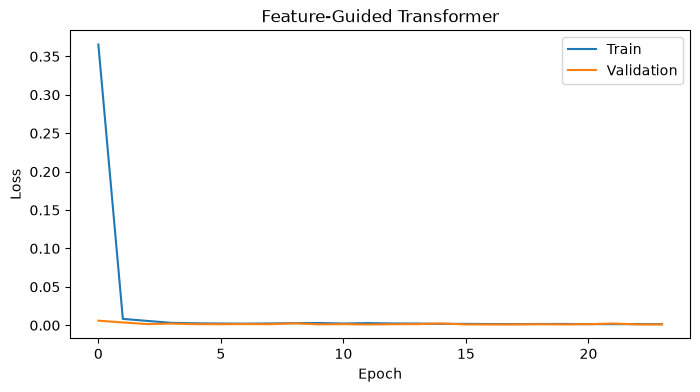

In [33]:
plt.figure(figsize=(8,4))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Feature-Guided Transformer")
plt.legend()
plt.show()

In [34]:
model.load_state_dict(torch.load("models/feature_guided_transformer.pth",weights_only=True))
model.eval()

FeatureGuidedTransformer(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attention): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): FeatureGuidedAttention(
          (context): FeatureContextModule(
            (projections): ModuleDict(
              (price): Linear(in_features=5, out_features=16, bias=True)
              (returns): Linear(in_features=4, out_features=16, bias=True)
              (volatility): Linear(in_features=7, out_features=16, bias=True)
              (momentum): Linear(in_features=5, out_features=16, bias=True)
              (trend): Linear(in_features=7, out_features=16, bias=True)
              (volume)

In [35]:
with torch.no_grad():
    predictions,_=model(X_test)

predictions=predictions.cpu().numpy()
targets=y_test.cpu().numpy()

In [36]:
mae=mean_absolute_error(targets,predictions)
rmse=np.sqrt(mean_squared_error(targets,predictions))
r2=r2_score(targets,predictions)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

MAE  : 0.032613
RMSE : 0.044231
R²   : -0.100367


In [37]:
metrics=evaluate_trading_metrics(
    targets,
    predictions
)

metrics

{'Directional Accuracy': np.float64(0.5214899713467048),
 'Hit Rate': np.float64(0.5214899713467048),
 'Sharpe': np.float64(0.5392128898679048),
 'Strategy Return': np.float32(0.21449244),
 'Max Drawdown': np.float32(-0.7013386)}

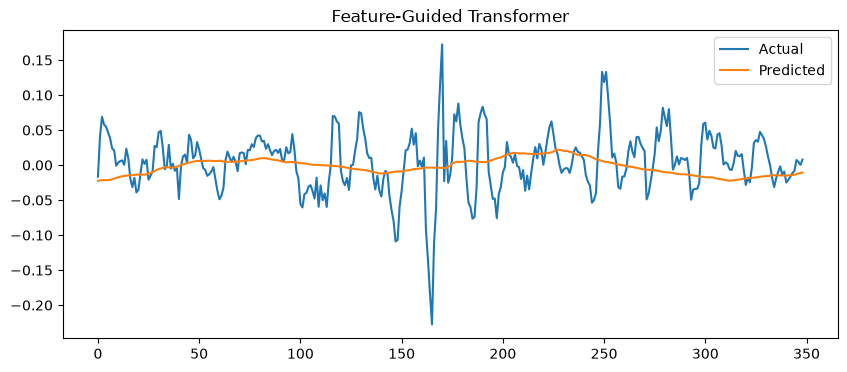

In [38]:
plt.figure(figsize=(10,4))
plt.plot(targets,label="Actual")
plt.plot(predictions,label="Predicted")
plt.legend()
plt.title("Feature-Guided Transformer")
plt.show()

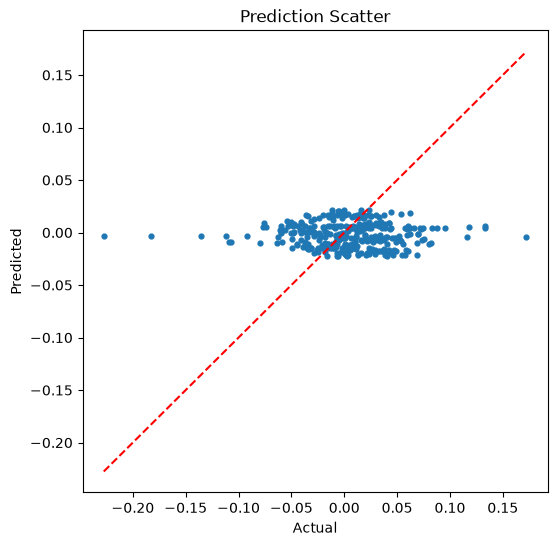

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(targets,predictions,s=12)
plt.plot(
    [targets.min(),targets.max()],
    [targets.min(),targets.max()],
    "r--"
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction Scatter")
plt.show()

In [41]:
with torch.no_grad():
    pred,attention=model(X_test)

pred=pred.cpu().numpy()
true=y_test.cpu().numpy()

In [42]:
metrics=evaluate_trading_metrics(true,pred)

for k,v in metrics.items():
    print(f"{k}: {v}")

Directional Accuracy: 0.5214899713467048
Hit Rate: 0.5214899713467048
Sharpe: 0.5392128898679048
Strategy Return: 0.21449244022369385
Max Drawdown: -0.7013385891914368


In [44]:
baseline=pd.read_csv("experiments/baseline_results.csv")

baseline.loc[len(baseline)]=[
    "Feature Guided Transformer",
    mae,
    rmse,
    r2
]

baseline.to_csv("experiments/baseline_results.csv",index=False)

baseline.sort_values("MAE")

,Model,MAE,RMSE,R2
6,Custom Transformer,0.030962,0.043111,-0.045353
5,PyTorch Transformer,0.032234,0.043543,-0.066416
9,Feature Guided Transformer,0.032613,0.044231,-0.100367
1,Random Forest,0.033050,0.045135,-0.145847
4,XGBoost,0.034423,0.045011,-0.139553
3,GRU,0.034453,0.047614,-0.275127
2,LSTM,0.040036,0.052256,-0.535912
8,Adaptive Financial Transformer,0.131486,0.152851,-12.141038
0,Linear Regression,0.188742,0.248706,-33.790931
7,Price Aware Transformer,0.280036,0.284159,-44.416771


In [45]:
trading=pd.read_csv("experiments/trading_results.csv")

trading.loc[len(trading)]=[
    "Feature Guided Transformer",
    metrics["Directional Accuracy"],
    metrics["Hit Rate"],
    metrics["Sharpe"],
    metrics["Strategy Return"],
    metrics["Max Drawdown"]
]

trading.to_csv("experiments/trading_results.csv",index=False)

trading.sort_values("Sharpe",ascending=False)

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
7,Price-Aware Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
8,Adaptive Financial Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
9,Feature Guided Transformer,0.521490,0.521490,0.539213,0.214492,-0.701339
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
6,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
5,PyTorch Transformer,0.441261,0.441261,-0.799614,-0.651581,-0.850522


In [47]:
experiment_log=pd.read_csv("experiments/experiment_log.csv")

experiment_log.loc[len(experiment_log)]={
    "Experiment":"Feature Guided Transformer",
    "Model":"Feature Guided Transformer",
    "Parameters":sum(p.numel() for p in model.parameters()),
    "Train Time (s)":round(train_time,2),
    "Epochs":best_epoch,
    "MAE":mae,
    "RMSE":rmse,
    "R2":r2,
    "Directional Accuracy":metrics["Directional Accuracy"],
    "Hit Rate":metrics["Hit Rate"],
    "Sharpe":metrics["Sharpe"],
    "Strategy Return":metrics["Strategy Return"],
    "Max Drawdown":metrics["Max Drawdown"],
    "Notes":"Dynamic gated adaptive financial attention"
}

experiment_log.to_csv("experiments/experiment_log.csv",index=False)

experiment_log.tail()

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
15,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.83,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.797920,Dynamic gated adaptive financial attention
16,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.83,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.797920,Dynamic gated adaptive financial attention
17,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.83,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.797920,Dynamic gated adaptive financial attention
18,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.83,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.797920,Dynamic gated adaptive financial attention
19,Feature Guided Transformer,Feature Guided Transformer,279457.0,23.31,17.0,0.032613,0.044231,-0.100367,0.52149,0.52149,0.539213,0.214492,-0.701339,Dynamic gated adaptive financial attention
